In [1]:

!pip install scikit-learn 

In [2]:
!pip install lightgbm 

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 4.7 MB/s  0:00:00


In [3]:
!pip install xgboost 

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 11.0 MB/s eta 0:00:10
   - -------------------------------------- 4.2/101.7 MB 14.0 MB/s eta 0:00:07
   -- ------------------------------------- 6.6/101.7 MB 12.7 MB/s eta 0:00:08
   --- ------------------------------------ 9.4/101.7 MB 13.0 MB/s eta 0:00:08
   ---- ----------------------------------- 12.1/101.7 MB 13.0 MB/s eta 0:00:07
   ----- ---------------------------------- 14.9/101.7 MB 13.2 MB/s eta 0:00:07
   ------- -------------------------------- 17.8/101.7 MB 13.4 MB/s eta 0:00:07
   -------- ------------------------------- 20.7/101.7 MB 13.4 MB/s eta 0:00:07
   -------- ------------------------------- 22.0/101.7 MB 12.9 MB/s eta 0:00:07
   --------- ------------------------------ 24.6/101.7 MB 12.6 MB/s eta 0:00:07
   ---------- ----------------------------- 27.5/101.7 MB 12.7 MB/s eta 0:00:06
   ----------- ---------------------------- 30.4/101.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

In [6]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


In [7]:
import warnings, os, random, json
warnings.filterwarnings("ignore")
sns.set(style="whitegrid", rc={"figure.figsize": (8,5)})
RND_SEED = 42

In [11]:
df   = pd.read_csv("Titanic_train(1&x).csv")
df_test = pd.read_csv("Titanic_test(1&x).csv")

In [12]:
print(f"Train shape: {df.shape}   |   Test shape: {df_test.shape}")
df.head()

Train shape: (891, 12)   |   Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


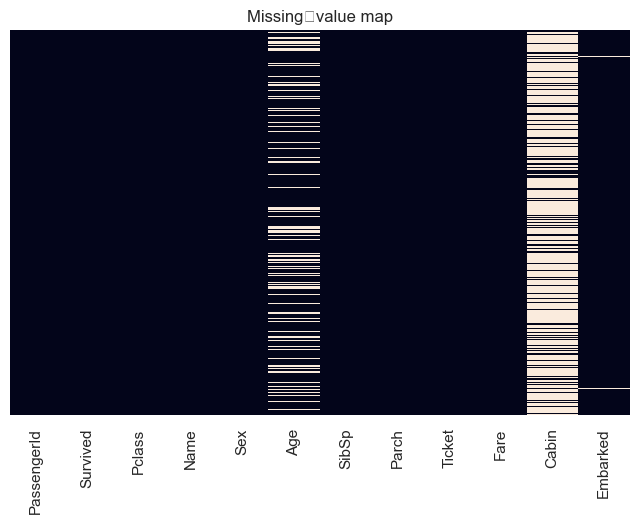

Missing values per column:
 Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64


In [13]:
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title("Missing‑value map"); plt.show()

print("Missing values per column:\n", df.isna().sum().sort_values(ascending=False))

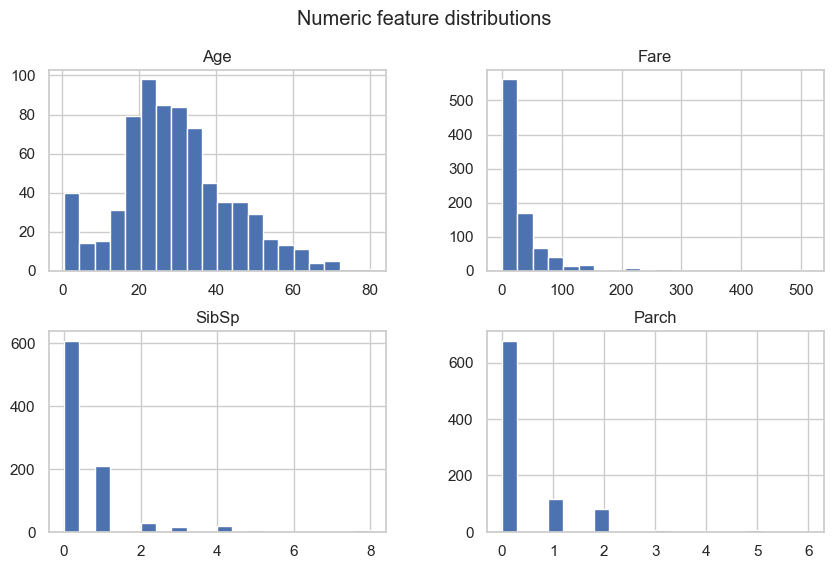

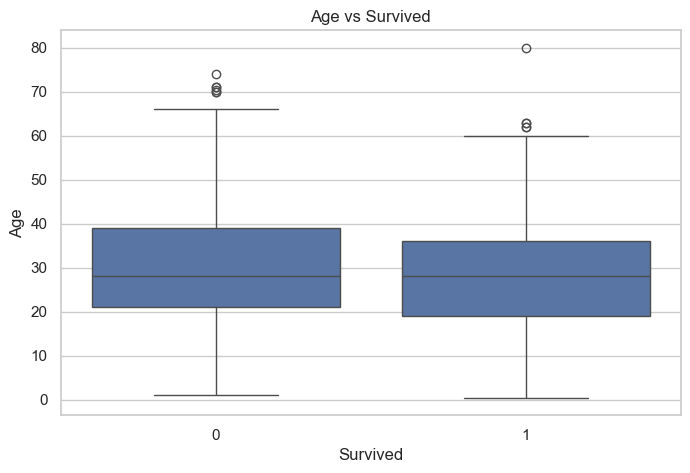

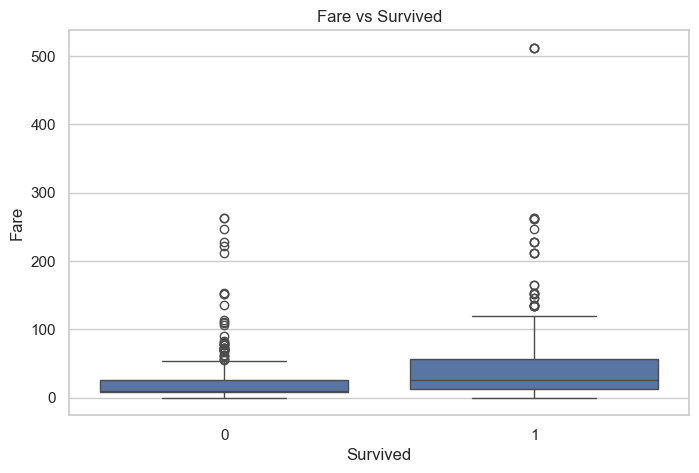

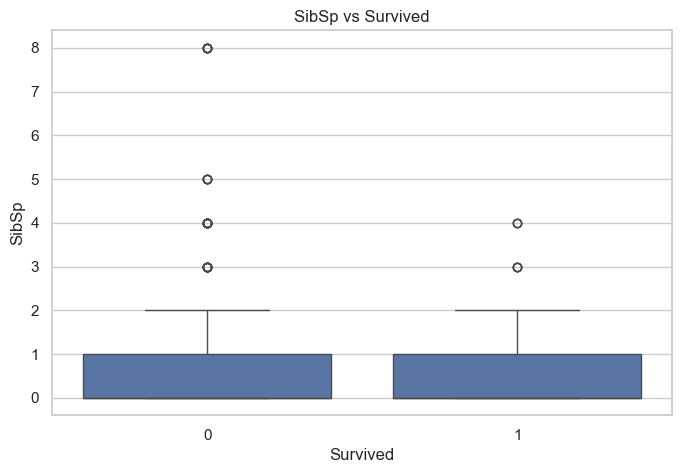

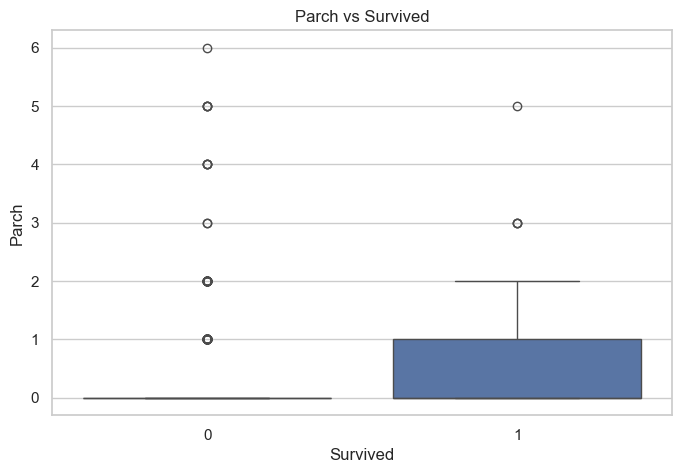

In [14]:
num_cols = ["Age", "Fare", "SibSp", "Parch"]
df[num_cols].hist(bins=20, layout=(2,2), figsize=(10,6))
plt.suptitle("Numeric feature distributions"); plt.show()


for col in num_cols:
    sns.boxplot(x="Survived", y=col, data=df)
    plt.title(f"{col} vs Survived"); plt.show()

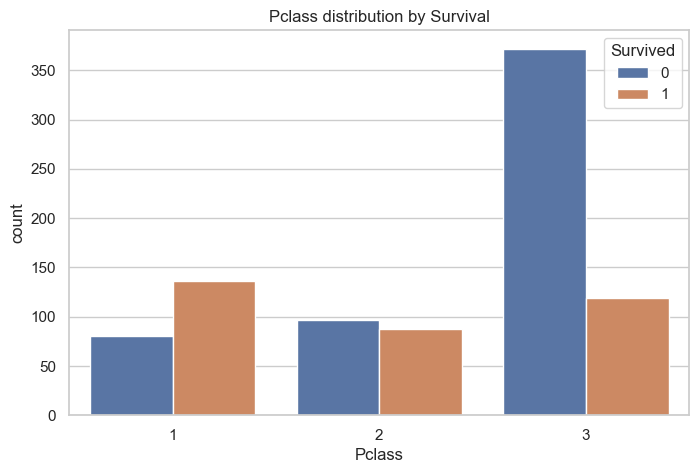

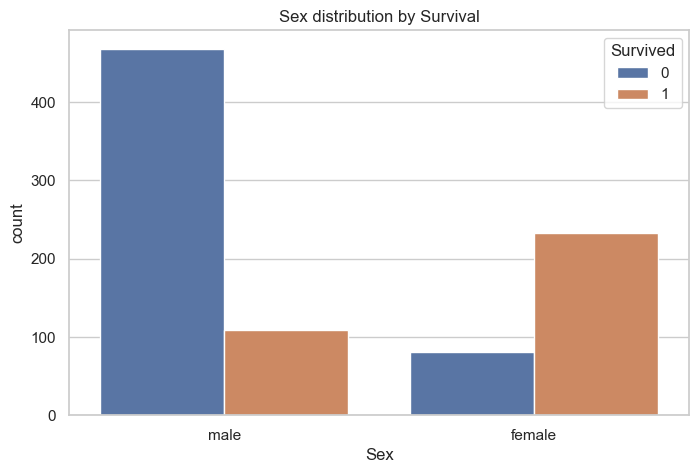

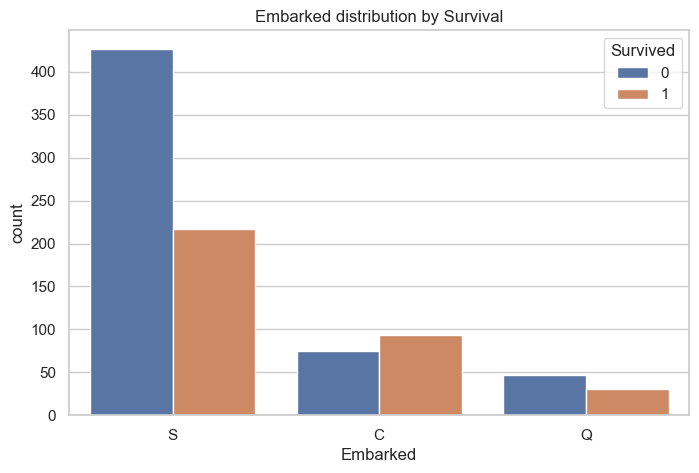

In [15]:
cat_cols = ["Pclass", "Sex", "Embarked"]
for col in cat_cols:
    sns.countplot(x=col, hue="Survived", data=df)
    plt.title(f"{col} distribution by Survival"); plt.show()

In [16]:
target = "Survived"
X = df.drop(columns=[target, "PassengerId", "Ticket", "Name", "Cabin"])
y = df[target]

numeric_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features)
])

In [17]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RND_SEED, stratify=y
)

print("Class balance in train:", y_train.value_counts(normalize=True))
print("Class balance in valid:", y_valid.value_counts(normalize=True))

Class balance in train: Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64
Class balance in valid: Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [18]:
lgbm_base = LGBMClassifier(
    random_state=RND_SEED,
    objective="binary",
    n_estimators=200,
    learning_rate=0.05
)

xgb_base = XGBClassifier(
    random_state=RND_SEED,
    eval_metric="logloss",
    n_estimators=200,
    learning_rate=0.05,
    use_label_encoder=False
)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND_SEED)

lgbm_param_grid = {
    "model__num_leaves":      [15, 31, 63, 127],
    "model__max_depth":       [-1, 3, 5, 7, 10],
    "model__min_child_samples":[10, 20, 30, 50],
    "model__subsample":       [0.6, 0.7, 0.8, 1.0],
    "model__colsample_bytree":[0.6, 0.7, 0.8, 1.0]
}

xgb_param_grid = {
    "model__max_depth":    [3, 4, 5, 6],
    "model__gamma":        [0, 0.1, 0.3],
    "model__subsample":    [0.6, 0.8, 1.0],
    "model__colsample_bytree":[0.6, 0.8, 1.0],
    "model__min_child_weight":[1, 5, 10]
}

def run_random_search(base_model, param_grid, name):
    pipe = Pipeline(steps=[("prep", preprocessor),
                           ("model", base_model)])
    search = RandomizedSearchCV(pipe,
                                param_distributions=param_grid,
                                n_iter=30,
                                scoring="accuracy",
                                cv=cv,
                                random_state=RND_SEED,
                                n_jobs=-1,
                                verbose=0)
    search.fit(X_train, y_train)
    print(f"\n  {name} best CV accuracy: {search.best_score_:.4f}")
    print(f"Best params: {json.dumps(search.best_params_, indent=2)}")
    return search.best_estimator_

lgbm_clf = run_random_search(lgbm_base, lgbm_param_grid, "LightGBM")
xgb_clf  = run_random_search(xgb_base,  xgb_param_grid,  "XGBoost")

In [ ]:
def evaluate(model, X_val, y_val, label):
    y_pred = model.predict(X_val)
    metrics = {
        "accuracy":  accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred),
        "recall":    recall_score(y_val, y_pred),
        "f1":        f1_score(y_val, y_pred)
    }
    print(f"\n  {label} scores on validation:")
    for k,v in metrics.items():
        print(f"   {k:<9}: {v:.4f}")
    return metrics, y_pred

lgbm_metrics, _ = evaluate(lgbm_clf, X_valid, y_valid, "LightGBM")
xgb_metrics,  _ = evaluate(xgb_clf,  X_valid, y_valid, "XGBoost")

In [ ]:
for m, name in zip([lgbm_clf, xgb_clf], ["LightGBM","XGBoost"]):
    sns.heatmap(
        confusion_matrix(y_valid, m.predict(X_valid)),
        annot=True, fmt="d", cmap="Blues"
    )
    plt.title(f"{name} Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()
    print(f"{name} classification report:\n",
          classification_report(y_valid, m.predict(X_valid)))

In [ ]:
metric_df = pd.DataFrame([lgbm_metrics, xgb_metrics], index=["LightGBM","XGBoost"])
metric_df.plot(kind="bar")
plt.title("Validation‑set metric comparison")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()
metric_df